In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
data = pd.read_parquet('../../data/processed_files/init_traj_step3_standardized_grids.zst')
data['stay_id'] = data['stay_id'].astype(int)

In [4]:
data.head()

,timestep,stay_id,timestamp,gender,age,charlson_comorbidity_index,re_admission,los,morta_hosp,morta_90,...,fluid_total,fluid_step,uo_total,uo_step,balance,vaso_median,vaso_max,abx_given,hours_since_first_abx,num_abx
0,1,30000484,5.239603e+09,1,92.0,7,0,2.478889,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,-3.65,0
1,2,30000484,5.239618e+09,1,92.0,7,0,2.478889,0.0,1.0,...,250.0,250.0,360.0,360.0,-110.0,0.0,0.0,1,0.35,1
2,3,30000484,5.239632e+09,1,92.0,7,0,2.478889,0.0,1.0,...,750.0,500.0,460.0,100.0,290.0,0.0,0.0,1,4.35,1
3,4,30000484,5.239646e+09,1,92.0,7,0,2.478889,0.0,1.0,...,1250.0,500.0,570.0,110.0,680.0,0.0,0.0,1,8.35,1
4,5,30000484,5.239661e+09,1,92.0,7,0,2.478889,0.0,1.0,...,1750.0,500.0,680.0,110.0,1070.0,0.0,0.0,1,12.35,1


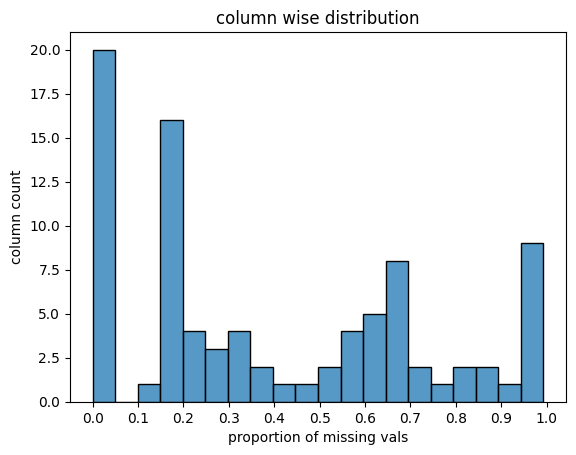

In [5]:
# column wise missingness
col_miss = data.isna().mean()

sns.histplot(col_miss, binwidth=0.05, stat = 'count')
plt.xticks(np.arange(0, 1.05, 0.1))
plt.xlabel('proportion of missing vals')
plt.ylabel('column count')
plt.title('column wise distribution')
plt.show()

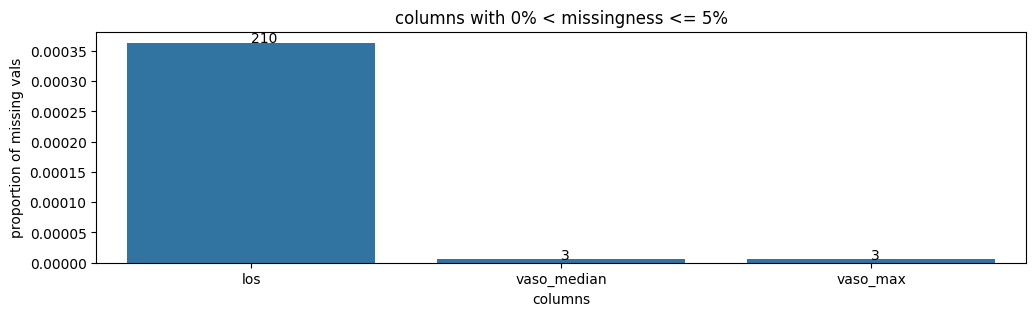

In [6]:
# cols with missingness < 0.05 but >0
plt.figure(figsize=(12, 3))
interesting_cols = col_miss[(col_miss <= 0.05) & (col_miss > 0)]
sns.barplot(x=interesting_cols.index, y=interesting_cols)
for i, col in enumerate(interesting_cols.index):
    plt.text(i, interesting_cols[col], data[col].isna().sum())
plt.xlabel('columns')
plt.ylabel('proportion of missing vals')
plt.title('columns with 0% < missingness <= 5%')
plt.show()


0.0022685185185185


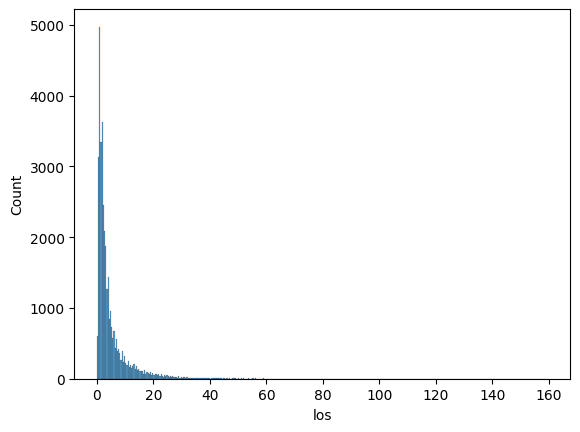

In [7]:
# los = length of stay
sns.histplot(data.drop_duplicates(subset = 'stay_id')['los'])
print(min(data.drop_duplicates(subset = 'stay_id')['los']))

In [8]:
# now we will check that within each stay_id the los is the same across all rows (it should be)
los_consistency = data.groupby('stay_id')['los'].nunique()
print(f"number of stay_ids with inconsistent los: {(los_consistency > 1).sum()}") 

# as there are no inconsistent los values, we will now see 
# if we can impute the missing los, with the los from the same stay_id
data['los'] = data.groupby('stay_id')['los'].transform(lambda x: x.bfill().ffill())
print(f'number of los values still missing: {data["los"].isna().sum()}')

number of stay_ids with inconsistent los: 0
number of los values still missing: 210


In [ ]:
# from above we can see that no los was imputed from using the stay_id
# so we will try and get the los from the icu stays file 
icu_stays = pd.read_csv('../../data/processed_files/icustays.csv', delimiter = '|')

stay_id_with_missing_los = data[data['los'].isna()]['stay_id']

icu_stays[icu_stays['stay_id'].isin(stay_id_with_missing_los)]

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
4486,10492274,29238609,38475410,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2165-03-18 09:34:15,NaN,NaN
8155,10882284,28910170,30924165,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2125-04-23 03:13:54,NaN,NaN
24344,12590282,27383443,38914513,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2185-04-03 02:19:38,NaN,NaN
40939,14330929,27393728,31619283,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2188-06-12 16:22:17,NaN,NaN
55595,15882332,24693580,36353950,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2178-03-27 19:18:14,NaN,NaN
57792,16117624,26745154,33009457,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-08-17 17:29:29,NaN,NaN
59939,16348177,22166548,34986686,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2151-10-05 18:47:26,NaN,NaN
82482,18717462,26658752,34314756,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2189-03-05 16:50:37,NaN,NaN
89915,19526758,27199762,34971926,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2153-07-02 08:35:23,NaN,NaN


In [13]:
# from the above, we see that the outtime is missing for the stay_ids with missing los, so we cannot get the los from the icu_stays files
# as there are only 9 stays with missing los, we will drop them
print(f'percentage of stay_ids with missing los: {(len(stay_id_with_missing_los)/len(data["stay_id"].unique()))*100:.2f}%')
data = data[~data['stay_id'].isin(stay_id_with_missing_los)]

percentage of stay_ids with missing los: 0.57%


,timestep,stay_id,timestamp,gender,age,charlson_comorbidity_index,re_admission,los,morta_hosp,morta_90,...,fluid_total,fluid_step,uo_total,uo_step,balance,vaso_median,vaso_max,abx_given,hours_since_first_abx,num_abx
152264,1,32604687,6.952582e+09,1,88.0,6,0,12.173449,0.0,0.0,...,0.000,360.613,260.0,260.0,-260.000,NaN,NaN,0,-0.233333,0
152265,2,32604687,6.952596e+09,1,88.0,6,0,12.173449,0.0,0.0,...,250.000,997.631,620.0,360.0,-370.000,NaN,NaN,1,3.766667,1
152266,3,32604687,6.952611e+09,1,88.0,6,0,12.173449,0.0,0.0,...,1437.218,1797.631,970.0,350.0,467.218,NaN,NaN,1,7.766667,1


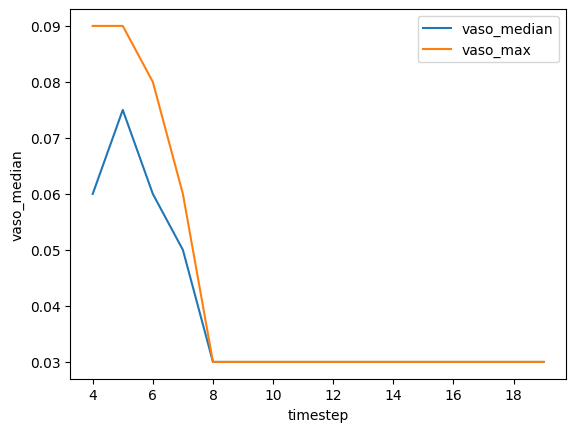

In [25]:
# now we look at the vaso_median and vaso_max values that are missing
display(data[data['vaso_max'].isna()])

# we see they are the same stay_id
sns.lineplot(data[data['stay_id'] == 32604687], x = 'timestep', y = 'vaso_median', label = 'vaso_median')
sns.lineplot(data[data['stay_id'] == 32604687], x = 'timestep', y = 'vaso_max', label = 'vaso_max')
plt.legend()
plt.show()

,timestep,stay_id,timestamp,gender,age,charlson_comorbidity_index,re_admission,los,morta_hosp,morta_90,...,fluid_total,fluid_step,uo_total,uo_step,balance,vaso_median,vaso_max,abx_given,hours_since_first_abx,num_abx


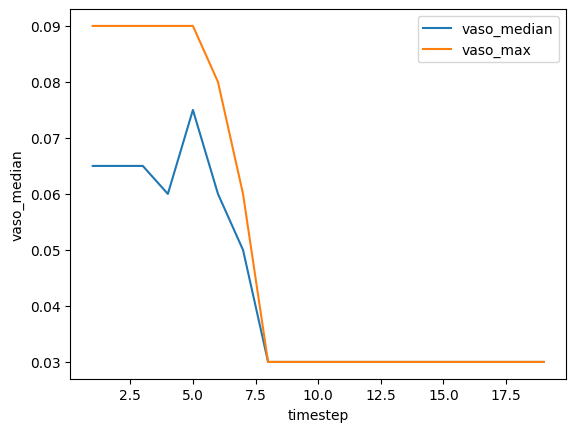

In [26]:
# from the plot above, we can see that at times 4-5/6, both vaso values are high 
# so, for the missing timestep values (1-3), we will impute with the mean of of the 4-5/6 timesteps

# for vaso_max, we impute with mean of timestep 4-5
data.loc[(data['stay_id'] == 32604687) & (data['timestep'] <= 3), 'vaso_max'] = data.loc[(data['stay_id'] == 32604687) & (data['timestep'].isin([4,5])), 'vaso_max'].mean()

# for vaso_median, we impute with mean of timestep 4-6
data.loc[(data['stay_id'] == 32604687) & (data['timestep'] <= 3), 'vaso_median'] = data.loc[(data['stay_id'] == 32604687) & (data['timestep'].isin([4,5,6])), 'vaso_median'].mean()


#displaying the result
sns.lineplot(data[data['stay_id'] == 32604687], x = 'timestep', y = 'vaso_median', label = 'vaso_median')
sns.lineplot(data[data['stay_id'] == 32604687], x = 'timestep', y = 'vaso_max', label = 'vaso_max')
plt.legend()
plt.show()

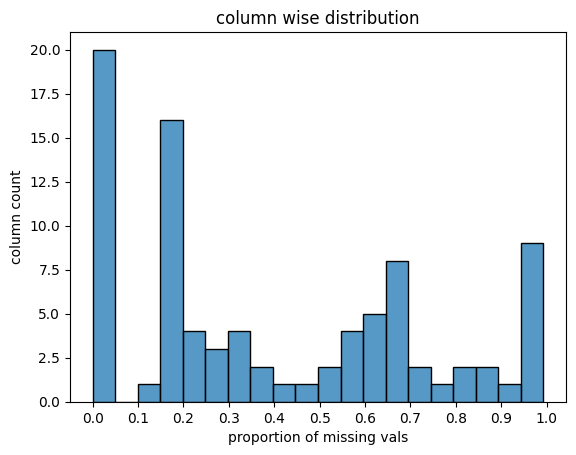

In [28]:
# relooking at the column wise missingness after imputation

# column wise missingness
col_miss = data.isna().mean()

sns.histplot(col_miss, binwidth=0.05, stat = 'count')
plt.xticks(np.arange(0, 1.05, 0.1))
plt.xlabel('proportion of missing vals')
plt.ylabel('column count')
plt.title('column wise distribution')
plt.show()

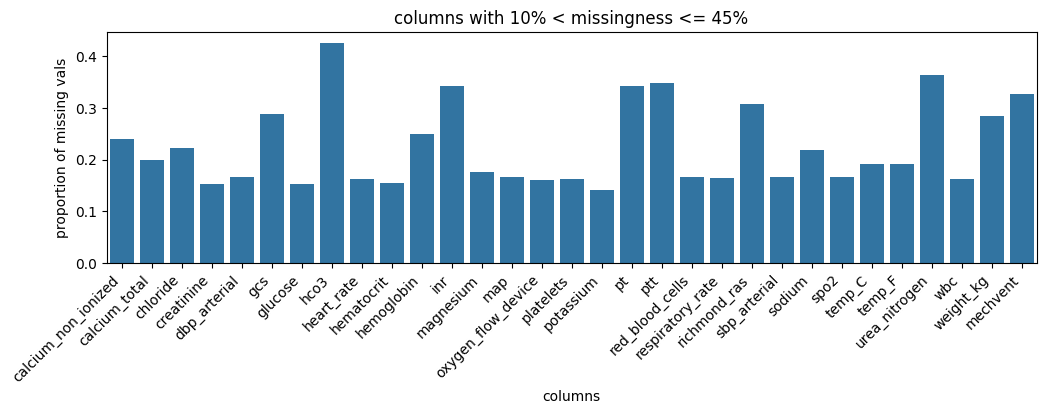

In [37]:
# we now look at the range between 0.1 and 0.45 missingness
plt.figure(figsize=(12, 3))
interesting_cols = col_miss[(col_miss <= 0.45) & (col_miss > 0.1)]
sns.barplot(x=interesting_cols.index, y=interesting_cols)
plt.xlabel('columns')
plt.ylabel('proportion of missing vals')
plt.title('columns with 10% < missingness <= 45%')
plt.xticks(rotation=45, ha='right')
plt.show()

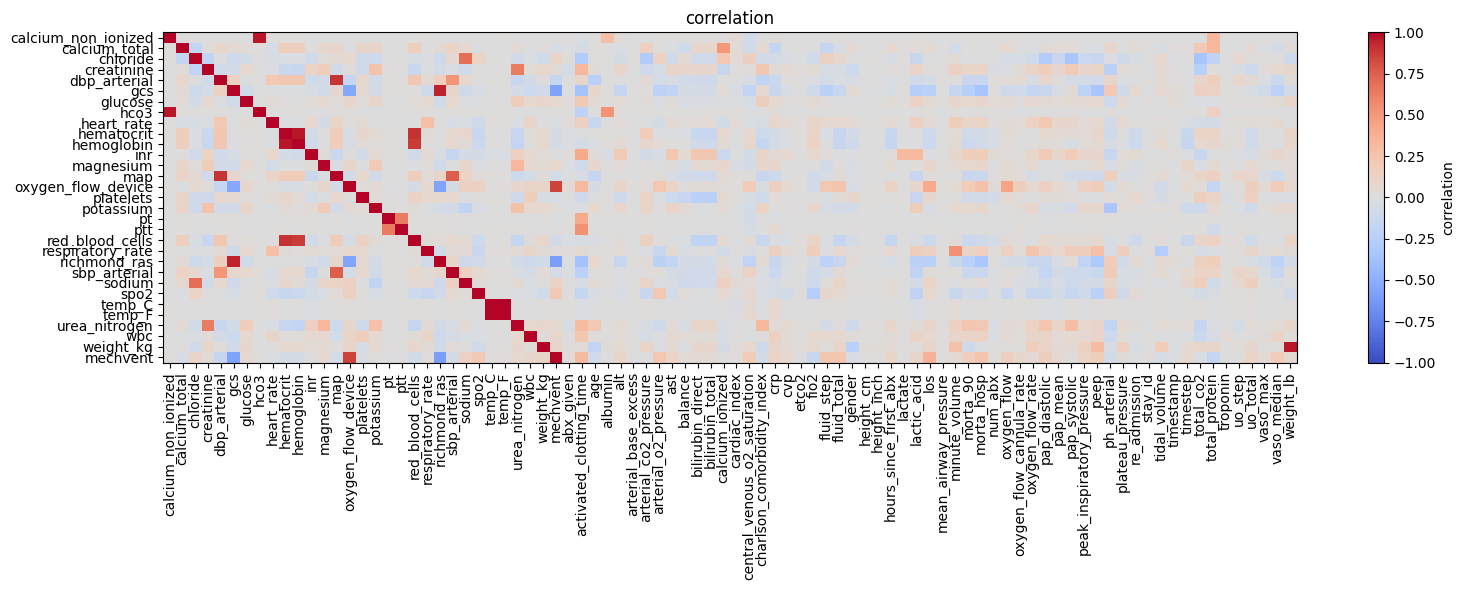

In [50]:
# make a heatmap-like plot of correlation between interesting columns and all numeric columns
num_cols = data.select_dtypes(include=np.number).columns

num_cols = interesting_cols.index.tolist() + num_cols.difference(interesting_cols.index).tolist()

corr_matrix = pd.DataFrame(
    {col: data[num_cols].corrwith(data[col]) for col in interesting_cols.index}
).T  # rows: interesting_cols, cols: all numeric cols


plt.figure(figsize=(16, 6))
im = plt.imshow(corr_matrix.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='correlation')

plt.yticks(np.arange(len(corr_matrix.index)), corr_matrix.index)
plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)

plt.title('correlation')
plt.tight_layout()
plt.show()
del corr_matrix